In [ ]:
from main_simulation import propagate_ephemeris, SimulationParameters, OrbitalParameters
from src.test_forces import ParameterizedTestForceParameters, TimeTestForceParameters
from src.parameters import TimeDependentParameter
from datetime import datetime, timedelta
from sympy import Symbol

arc_length = 86400.0
time_step = 10.0
arc_start_datetime = datetime(year=2000, month=1, day=1, hour=0, minute=0, second=0, microsecond=0)
simulation_parameters = SimulationParameters(
    time_step=time_step,
    satellite="test_satellite",
    simulated_forces={
        "central_body_attraction": None,
        "parameterized_test_force": ParameterizedTestForceParameters(
            dummy_parameter=Symbol("dummy_parameter"), dummy_parameter_value=1e-3
        ),
        "time_test_force": TimeTestForceParameters(
            time_dependent_parameter=TimeDependentParameter(
                symbol="time_dependent_parameter",
                arc_start_datetime=arc_start_datetime,
                datetime_sampling_values=[
                    arc_start_datetime + timedelta(seconds=seconds)
                    for seconds in range(0, int(arc_length + 1), 1000)
                ],
                parameter_values=[
                    1e-3 * delta_value * time_step
                    for delta_value in range(int(arc_length // time_step) + 1)
                ],
            )
        ),
    },
    arc_start_datetime=arc_start_datetime,
    arc_length=arc_length,
)

parameter_expressions = {
    "Earth_radius": Symbol("Earth_radius"),
    "gravitational_parameter": Symbol("gravitational_parameter"),
    "t": Symbol("t"),
    "semi_major_axis": Symbol("semi_major_axis"),
    "eccentricity": Symbol("eccentricity"),
    "inclination": Symbol("inclination"),
    "right_ascension_ascending_node": Symbol("right_ascension_ascending_node"),
    "argument_of_periapsis": Symbol("argument_of_periapsis"),
    "true_anomaly": Symbol("true_anomaly"),
}
terminal_parameter_values = {
    "gravitational_parameter": 3.986004418e14,
    "Earth_radius": 6.371e6,
    "semi_major_axis": 7e6,
    "eccentricity": 0.05,
    "inclination": 45.0,
    "right_ascension_ascending_node": 0.0,
    "argument_of_periapsis": 0.0,
    "true_anomaly": 0.0,
}

for _, force_parameters in simulation_parameters.simulated_forces.items():

    if force_parameters:

        parameter_expressions.update(force_parameters.get_parameter_expressions())
        terminal_parameter_values.update(force_parameters.get_terminal_parameters())

initial_conditions = OrbitalParameters()

t, y, generalized_symbolic_propagator = propagate_ephemeris(
    simulation_parameters=simulation_parameters,
    parameter_expressions=parameter_expressions,
    terminal_parameter_values=terminal_parameter_values,
    initial_conditions=initial_conditions,
)

/tmp/ipykernel_84621/3493250049.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


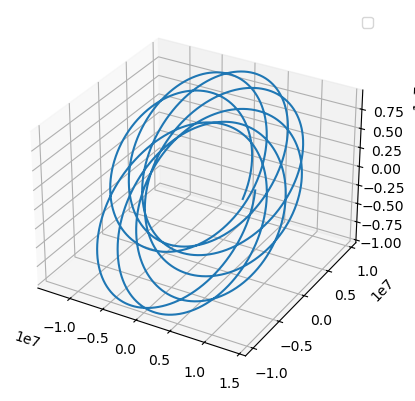

In [2]:
import matplotlib.pyplot as plt

ax = plt.figure().add_subplot(projection="3d")

ax.plot(y[:, 0], y[:, 1], y[:, 2])
ax.legend()

plt.show()